In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pybaseball import statcast_pitcher, playerid_lookup

plt.style.use('seaborn-v0_8-whitegrid')

cease_info = playerid_lookup('cease', 'dylan')
print(cease_info)

Gathering player lookup table. This may take a moment.
  name_last name_first  key_mlbam key_retro  key_bbref  key_fangraphs  \
0     cease      dylan     656302  ceasd001  ceasedy01          18525   

   mlb_played_first  mlb_played_last  
0            2019.0           2025.0  


In [2]:
cease_id = 656302

cease_2026 = statcast_pitcher('2026-03-27', '2026-04-22', cease_id)
print(f"2026 pitches: {len(cease_2026)}")

Gathering Player Data
2026 pitches: 495


In [3]:
cease_2025 = statcast_pitcher('2025-03-20', '2025-10-01', cease_id)
print(f"2025 pitches: {len(cease_2025)}")

Gathering Player Data
2025 pitches: 3199


In [4]:
cease_2024 = statcast_pitcher('2024-03-20', '2024-10-01', cease_id)
print(f"2024 pitches: {len(cease_2024)}")

Gathering Player Data
2024 pitches: 3263


In [5]:
print("=== Cease 2026 Pitch Mix ===")
print(cease_2026['pitch_type'].value_counts())

print("\n=== Avg Velocity by Pitch ===")
pitch_speed = cease_2026.groupby('pitch_type')['release_speed'].agg(['mean', 'count'])
pitch_speed = pitch_speed[pitch_speed['count'] >= 5].sort_values('mean', ascending=False)
print(pitch_speed.round(1))

=== Cease 2026 Pitch Mix ===
pitch_type
FF    191
SL    137
CH     47
ST     41
KC     41
SI     38
Name: count, dtype: int64

=== Avg Velocity by Pitch ===
            mean  count
pitch_type             
FF          98.0    191
SI          96.7     38
SL          89.5    137
ST          84.5     41
CH          84.5     47
KC          83.0     41


In [6]:
cease_2026.to_csv('../data/cease_2026.csv', index=False)
cease_2025.to_csv('../data/cease_2025.csv', index=False)
cease_2024.to_csv('../data/cease_2024.csv', index=False)
print(f"Cease saved: {len(cease_2026)} + {len(cease_2025)} + {len(cease_2024)}")

Cease saved: 495 + 3199 + 3263


In [7]:
gausman_id = 592332
lauer_id = 641778

gausman_2026 = statcast_pitcher('2026-03-27', '2026-04-22', gausman_id)
print(f"Gausman 2026: {len(gausman_2026)}")

lauer_2026 = statcast_pitcher('2026-03-27', '2026-04-22', lauer_id)
print(f"Lauer 2026: {len(lauer_2026)}")

gausman_2025 = statcast_pitcher('2025-03-20', '2025-10-01', gausman_id)
print(f"Gausman 2025: {len(gausman_2025)}")

lauer_2025 = statcast_pitcher('2025-03-20', '2025-10-01', lauer_id)
print(f"Lauer 2025: {len(lauer_2025)}")

Gathering Player Data
Gausman 2026: 439
Gathering Player Data
Lauer 2026: 314
Gathering Player Data
Gausman 2025: 3038
Gathering Player Data
Lauer 2025: 1690


In [8]:
gausman_2026.to_csv('../data/gausman_2026.csv', index=False)
gausman_2025.to_csv('../data/gausman_2025.csv', index=False)
lauer_2026.to_csv('../data/lauer_2026.csv', index=False)
lauer_2025.to_csv('../data/lauer_2025.csv', index=False)
print("All data saved!")

All data saved!


In [9]:
cease_2024['season'] = 2024
cease_2025['season'] = 2025
cease_2026['season'] = 2026

all_cease = pd.concat([cease_2024, cease_2025, cease_2026])

pitch_mix_by_year = all_cease.groupby(['season', 'pitch_type']).size().unstack(fill_value=0)
pitch_pct = pitch_mix_by_year.div(pitch_mix_by_year.sum(axis=1), axis=0) * 100

print("=== Cease Pitch Mix % by Season ===")
print(pitch_pct.round(1))

=== Cease Pitch Mix % by Season ===
pitch_type   CH   FC    FF   KC   SI    SL   ST
season                                         
2024        0.9  0.6  43.4  8.1  0.1  42.7  4.2
2025        1.5  0.0  42.1  8.2  4.0  40.7  3.5
2026        9.5  0.0  38.6  8.3  7.7  27.7  8.3


In [10]:
def calc_whiff_rate(df):
    swings = df[df['description'].isin([
        'swinging_strike', 'swinging_strike_blocked',
        'foul', 'foul_tip', 'hit_into_play', 'foul_bunt',
        'hit_into_play_no_out', 'hit_into_play_score'
    ])]
    whiffs = df[df['description'].isin([
        'swinging_strike', 'swinging_strike_blocked'
    ])]
    if len(swings) == 0:
        return 0
    return len(whiffs) / len(swings) * 100

whiff_by_pitch_2026 = {}
for pitch in cease_2026['pitch_type'].unique():
    data = cease_2026[cease_2026['pitch_type'] == pitch]
    if len(data) >= 10:
        whiff_by_pitch_2026[pitch] = round(calc_whiff_rate(data), 1)

print("=== Cease 2026 Whiff Rate by Pitch ===")
for pitch, rate in sorted(whiff_by_pitch_2026.items(), key=lambda x: x[1], reverse=True):
    print(f"{pitch}: {rate}%")

=== Cease 2026 Whiff Rate by Pitch ===
CH: 69.2%
SL: 50.7%
ST: 33.3%
FF: 30.4%
KC: 28.6%
SI: 5.6%


Chart saved!


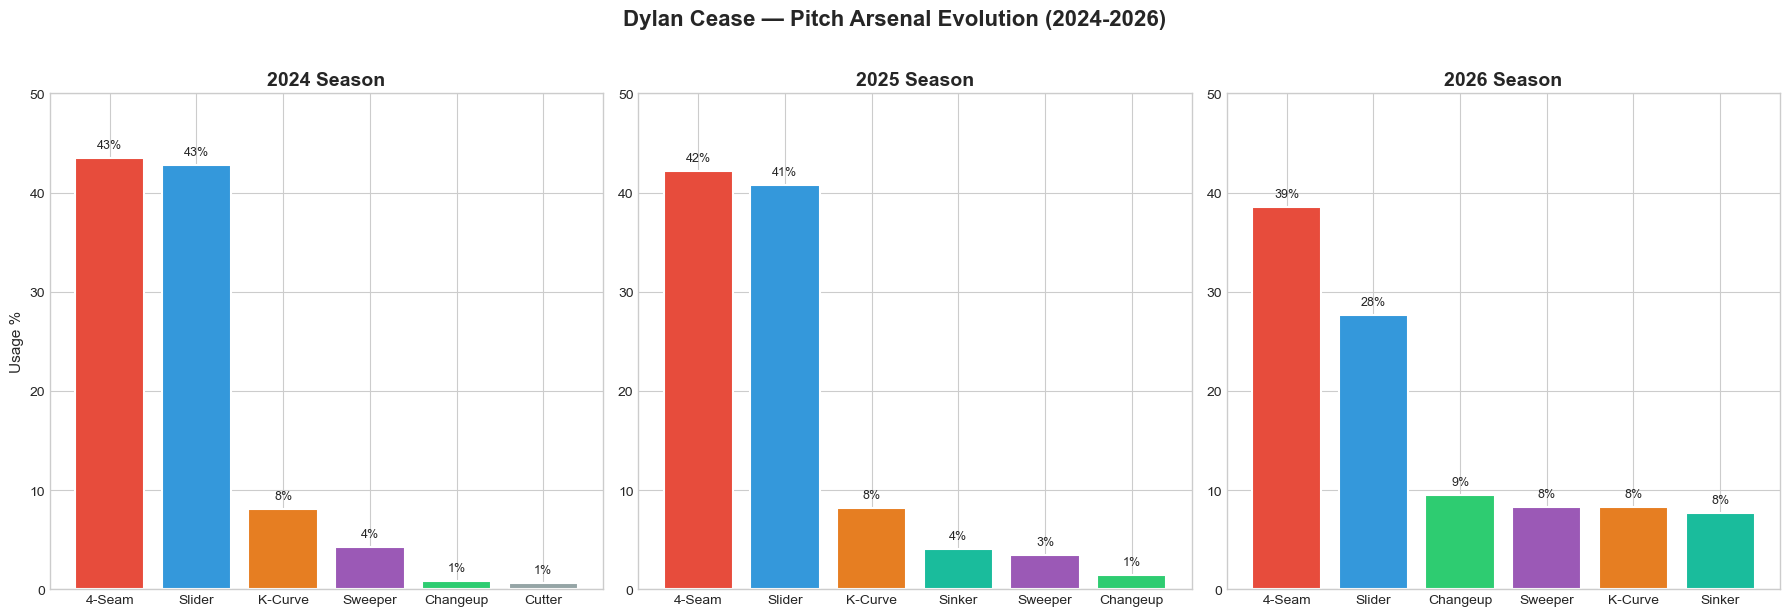

In [11]:
pitch_names = {
    'FF': '4-Seam', 'SL': 'Slider', 'CH': 'Changeup',
    'ST': 'Sweeper', 'KC': 'K-Curve', 'SI': 'Sinker',
    'CU': 'Curveball', 'FC': 'Cutter'
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, (season, data) in enumerate([(2024, cease_2024), (2025, cease_2025), (2026, cease_2026)]):
    ax = axes[idx]
    pitch_counts = data['pitch_type'].value_counts()
    pitch_counts = pitch_counts[pitch_counts >= 10]
    
    colors = {'FF': '#e74c3c', 'SL': '#3498db', 'CH': '#2ecc71',
              'ST': '#9b59b6', 'KC': '#e67e22', 'SI': '#1abc9c',
              'CU': '#f39c12', 'FC': '#95a5a6'}
    
    bar_colors = [colors.get(p, '#95a5a6') for p in pitch_counts.index]
    labels = [pitch_names.get(p, p) for p in pitch_counts.index]
    
    ax.bar(labels, pitch_counts.values / pitch_counts.values.sum() * 100,
           color=bar_colors, edgecolor='white', linewidth=1.5)
    ax.set_title(f'{season} Season', fontsize=14, fontweight='bold')
    ax.set_ylabel('Usage %' if idx == 0 else '', fontsize=11)
    ax.set_ylim(0, 50)
    
    for i, v in enumerate(pitch_counts.values / pitch_counts.values.sum() * 100):
        ax.text(i, v + 1, f'{v:.0f}%', ha='center', fontsize=9)

plt.suptitle("Dylan Cease — Pitch Arsenal Evolution (2024-2026)",
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../visualizations/01_cease_pitch_arsenal.png', dpi=150, bbox_inches='tight')
print("Chart saved!")
plt.show()

Chart saved!


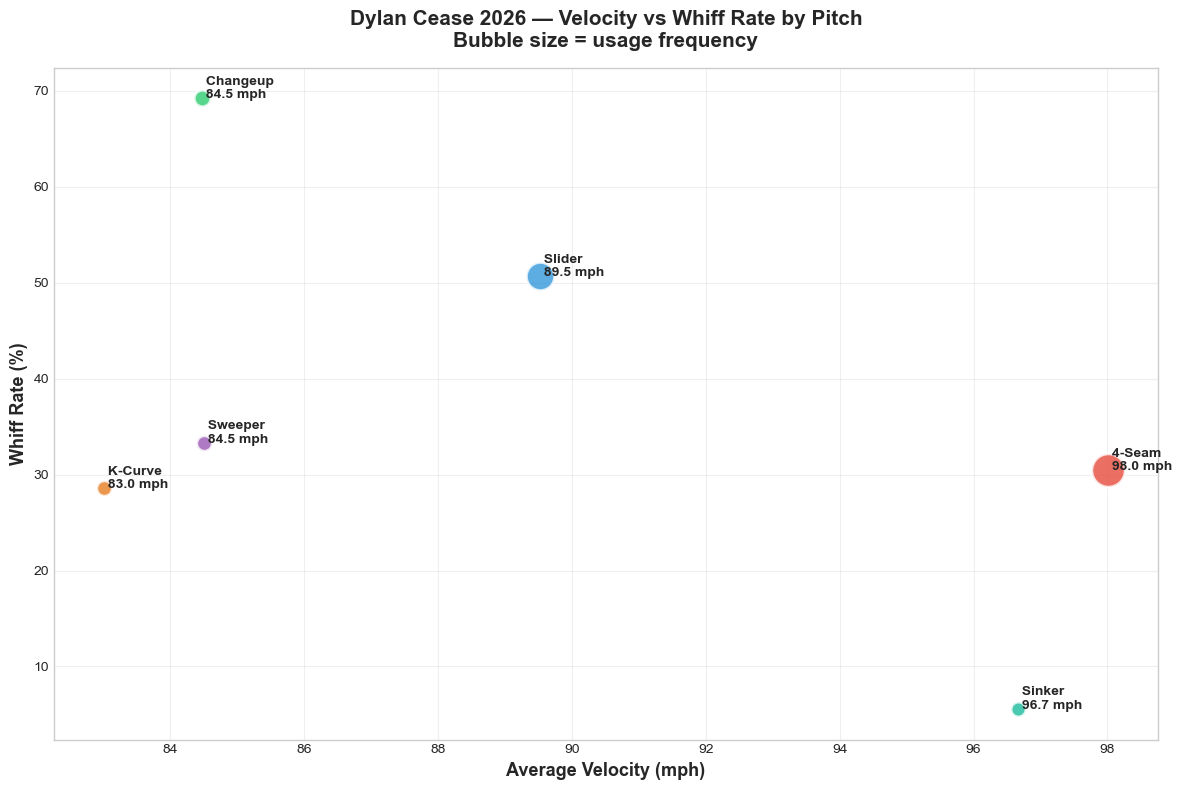

In [12]:
fig, ax = plt.subplots(figsize=(12, 8))

pitch_colors = {'FF': '#e74c3c', 'SL': '#3498db', 'CH': '#2ecc71',
                'ST': '#9b59b6', 'KC': '#e67e22', 'SI': '#1abc9c'}

for pitch_type in cease_2026['pitch_type'].unique():
    data = cease_2026[cease_2026['pitch_type'] == pitch_type]
    if len(data) >= 10:
        avg_velo = data['release_speed'].mean()
        whiff = calc_whiff_rate(data)
        count = len(data)
        
        color = pitch_colors.get(pitch_type, '#95a5a6')
        ax.scatter(avg_velo, whiff, s=count * 3, c=color,
                   edgecolors='white', linewidth=2, zorder=3, alpha=0.8)
        ax.annotate(f" {pitch_names.get(pitch_type, pitch_type)}\n {avg_velo:.1f} mph",
                    xy=(avg_velo, whiff), fontsize=10, fontweight='bold')

ax.set_xlabel('Average Velocity (mph)', fontsize=13, fontweight='bold')
ax.set_ylabel('Whiff Rate (%)', fontsize=13, fontweight='bold')
ax.set_title("Dylan Cease 2026 — Velocity vs Whiff Rate by Pitch\n"
             "Bubble size = usage frequency",
             fontsize=15, fontweight='bold', pad=15)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../visualizations/02_cease_velo_whiff.png', dpi=150, bbox_inches='tight')
print("Chart saved!")
plt.show()

Chart saved!


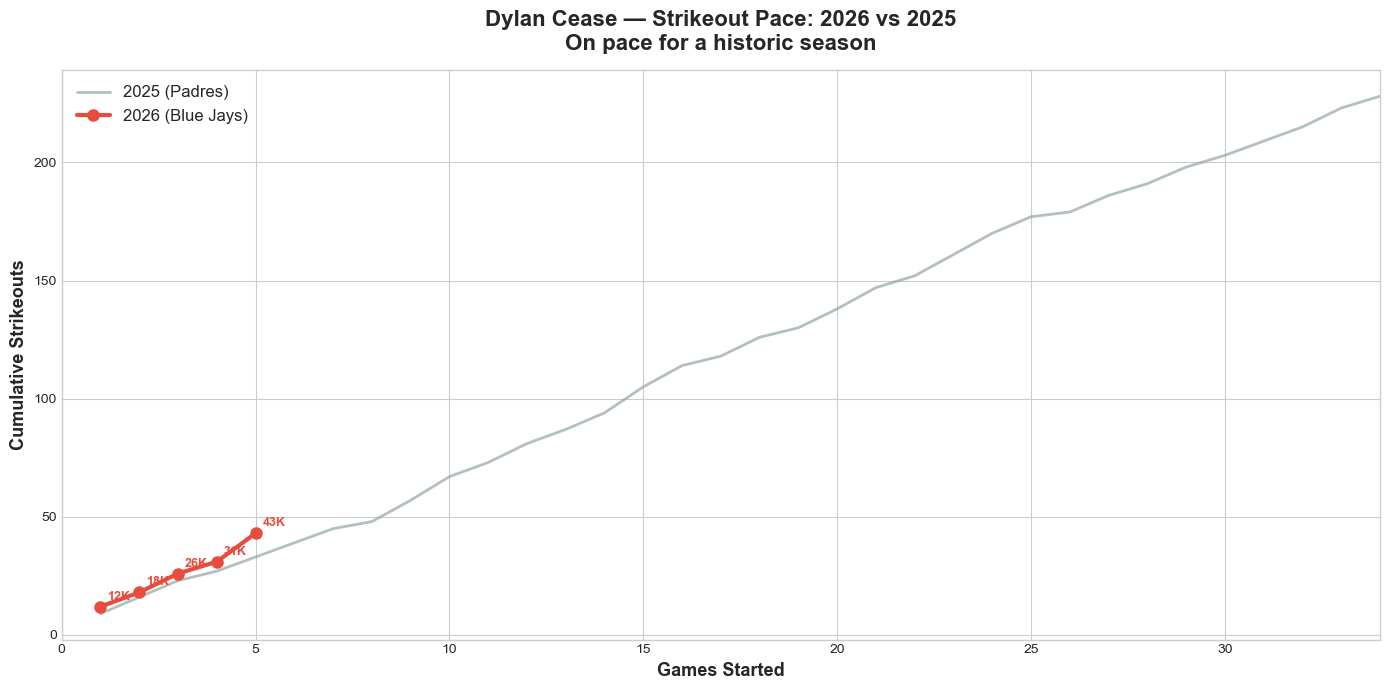

In [13]:
cease_2026_games = cease_2026.groupby('game_date').agg(
    strikeouts=('events', lambda x: (x == 'strikeout').sum())
).reset_index()

cease_2026_games = cease_2026_games.sort_values('game_date')
cease_2026_games['cumulative_k'] = cease_2026_games['strikeouts'].cumsum()
cease_2026_games['game_num'] = range(1, len(cease_2026_games) + 1)

cease_2025_games = cease_2025.groupby('game_date').agg(
    strikeouts=('events', lambda x: (x == 'strikeout').sum())
).reset_index()
cease_2025_games = cease_2025_games.sort_values('game_date')
cease_2025_games['cumulative_k'] = cease_2025_games['strikeouts'].cumsum()
cease_2025_games['game_num'] = range(1, len(cease_2025_games) + 1)

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(cease_2025_games['game_num'], cease_2025_games['cumulative_k'],
        color='#95a5a6', linewidth=2, label='2025 (Padres)', alpha=0.7)

ax.plot(cease_2026_games['game_num'], cease_2026_games['cumulative_k'],
        color='#e74c3c', linewidth=3, marker='o', markersize=8,
        label='2026 (Blue Jays)')

for _, row in cease_2026_games.iterrows():
    ax.annotate(f"{int(row['cumulative_k'])}K",
                xy=(row['game_num'], row['cumulative_k']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=9, color='#e74c3c', fontweight='bold')

ax.set_xlabel('Games Started', fontsize=13, fontweight='bold')
ax.set_ylabel('Cumulative Strikeouts', fontsize=13, fontweight='bold')
ax.set_title("Dylan Cease — Strikeout Pace: 2026 vs 2025\n"
             "On pace for a historic season",
             fontsize=16, fontweight='bold', pad=15)
ax.legend(fontsize=12)
ax.set_xlim(0, max(cease_2025_games['game_num'].max(), 10))

plt.tight_layout()
plt.savefig('../visualizations/03_cease_strikeout_pace.png', dpi=150, bbox_inches='tight')
print("Chart saved!")
plt.show()